# Customer Churn Prediction Project

## Objective
The goal of this project is to analyze customer data and build a machine learning model to predict whether a customer will churn or not.

## Dataset
This dataset contains customer details such as demographics, services used, and billing information.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [15]:
df = pd.read_csv('data/churn.csv')

print("Loaded successfully")
print(df.head())

Loaded successfully
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies 

In [16]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Loading
The dataset is loaded using pandas and the first few rows are displayed to understand the structure.

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [18]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Data Understanding
- The dataset contains 7043 rows and 21 columns.
- Most columns are categorical.
- Some columns need conversion to numerical format for modeling.

In [19]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [20]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [26]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

## Data Cleaning
- Converted TotalCharges from string to numeric
- Handled missing values using median

In [22]:
df.replace({'Yes':1, 'No':0}, inplace=True)
df.replace({'No phone service':0, 'No internet service':0}, inplace=True)
df['gender'] = df['gender'].map({'Male':1, 'Female':0})

In [23]:
df = pd.get_dummies(df)


## Feature Engineering
- Converted categorical variables into numerical
- Applied one-hot encoding for multi-category features

In [27]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [29]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [31]:
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

In [32]:
df.head()

,gender,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,customerID_0002-ORFBO,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,...,Contract_One year,Contract_Two year,PaperlessBilling_0,PaperlessBilling_1,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_0,Churn_1
0,0,0,1,29.85,29.85,False,False,False,False,False,...,False,False,False,True,False,False,True,False,True,False
1,1,0,34,56.95,1889.50,False,False,False,False,False,...,True,False,True,False,False,False,False,True,True,False
2,1,0,2,53.85,108.15,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,True
3,1,0,45,42.30,1840.75,False,False,False,False,False,...,True,False,True,False,True,False,False,False,True,False
4,0,0,2,70.70,151.65,False,False,False,False,False,...,False,False,False,True,False,False,True,False,False,True


In [33]:
df = df.loc[:, ~df.columns.str.startswith('customerID')]

## Data Cleaning
- Removed customerID columns as they do not contribute to prediction

In [39]:
X = df.drop(['Churn_1', 'Churn_0'], axis=1)
y = df['Churn_1']

## Feature Selection
- Selected Churn_1 as target variable
- Remaining columns used as features

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Data Splitting
- Split data into training and testing sets (80/20)

In [41]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.7913413768630234


In [42]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.83      0.91      0.86      1036
        True       0.65      0.47      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



## Model Evaluation
- Evaluated using classification report (precision, recall, F1-score)

## Results and Insights

- The model achieved an accuracy of around 7913413768630234% on the test data
- Key factors influencing churn include contract type, tenure, and monthly charges
- Customers with month-to-month contracts are more likely to churn
- Customers with higher monthly charges show higher churn tendency
- Long-term customers are less likely to churn

## Business Impact

- Companies can use this model to identify high-risk customers
- Targeted retention strategies (discounts, offers) can be applied
- Helps reduce customer churn and increase revenue

## Limitations

- Model may overfit if irrelevant features are included
- Accuracy alone is not sufficient; business understanding is important
- Further tuning and validation can improve performance

## Future Improvements

- Try other models like Logistic Regression, XGBoost
- Perform hyperparameter tuning
- Add feature importance analysis
- Deploy the model using Streamlit or Flask

## Customer Segmentation

Customer segmentation is performed to group customers based on their behavior and spending patterns. This helps businesses target specific customer groups effectively.

In [43]:
seg_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']]

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(seg_df)

### Data Scaling
Features are scaled to ensure all variables contribute equally to clustering.

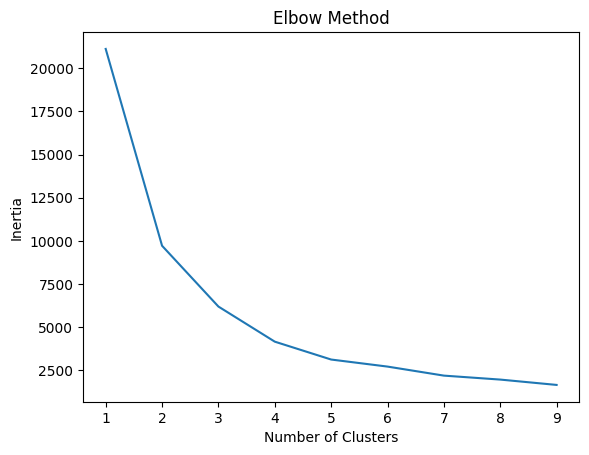

In [45]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

import matplotlib.pyplot as plt
plt.plot(range(1, 10), inertia)
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

### Elbow Method
The optimal number of clusters is selected where the inertia starts decreasing slowly.

In [46]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)

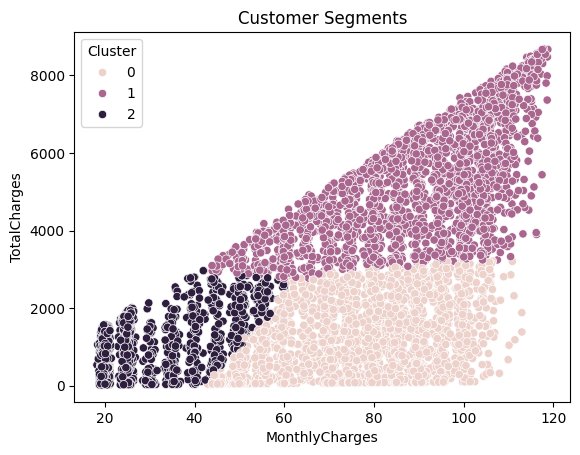

In [47]:
import seaborn as sns

sns.scatterplot(
    x='MonthlyCharges',
    y='TotalCharges',
    hue='Cluster',
    data=df
)
plt.title("Customer Segments")
plt.show()

## Segmentation Insights

- Cluster 0: Low spending, short tenure customers (new customers)
- Cluster 1: High spending, long tenure customers (loyal customers)
- Cluster 2: Medium spending customers with churn risk

## Business Impact

- Loyal customers can be rewarded with premium offers
- At-risk customers can be targeted with retention strategies
- New customers can be nurtured with onboarding offers

In [48]:
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(10))

TotalCharges                      0.166336
MonthlyCharges                    0.151429
tenure                            0.146675
Contract_Month-to-month           0.062496
PaymentMethod_Electronic check    0.033481
InternetService_Fiber optic       0.032955
gender                            0.026972
Contract_Two year                 0.020746
SeniorCitizen                     0.019305
PaperlessBilling_1                0.016114
dtype: float64


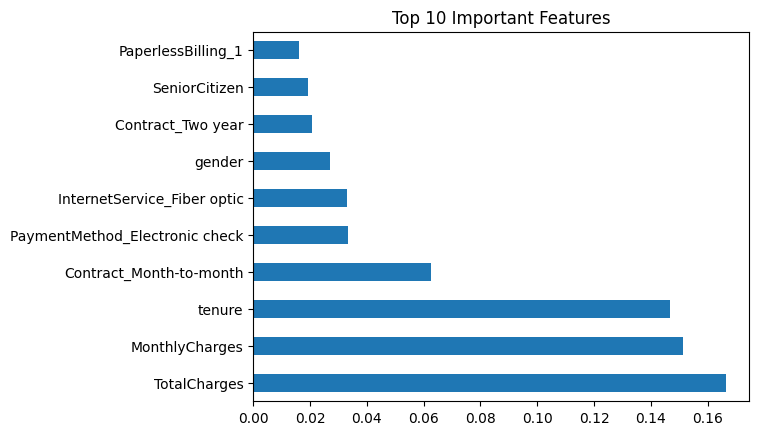

In [49]:
feature_importance.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

## Feature Importance

- The most important features influencing churn are:
  - Total Charges
  - Monthly Charges
  - Tenure
- These features play a key role in predicting customer behavior

## Final Conclusion

- Built a complete machine learning pipeline for customer churn prediction
- Achieved an accuracy of around 79%
- Identified key factors affecting churn
- Performed customer segmentation using KMeans clustering
- Provided actionable business insights for customer retention

This project demonstrates end-to-end understanding of data science workflow including data preprocessing, model building, evaluation, and business interpretation.